In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

In [3]:
df = pd.read_csv("full_dataset.csv")

df.head()

,cpg_density,genomic_location,regulatory_score,conservation_score,methylation_status
0,0.799343,0.949839,0.297447,0.268438,1
1,0.672347,0.831158,0.456644,0.477923,1
2,0.829538,0.614908,0.262274,0.567279,0
3,1.000000,0.438266,0.407612,1.000000,1
4,0.653169,0.774556,0.000000,0.761311,0


In [4]:
print(df.shape)
df.info()

(1000, 5)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   cpg_density         1000 non-null   float64
 1   genomic_location    1000 non-null   float64
 2   regulatory_score    1000 non-null   float64
 3   conservation_score  1000 non-null   float64
 4   methylation_status  1000 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 39.2 KB


In [5]:
df.isnull().sum()

cpg_density           0
genomic_location      0
regulatory_score      0
conservation_score    0
methylation_status    0
dtype: int64

In [6]:
df.describe()

,cpg_density,genomic_location,regulatory_score,conservation_score,methylation_status
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,0.697508,0.611986,0.501159,0.643147,0.554000
std,0.183028,0.234104,0.270085,0.198944,0.497324
min,0.051747,0.000000,0.000000,0.064110,0.000000
25%,0.570482,0.448440,0.305600,0.502516,0.000000
50%,0.705060,0.615769,0.499925,0.650037,1.000000
75%,0.829589,0.782221,0.698275,0.783389,1.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000


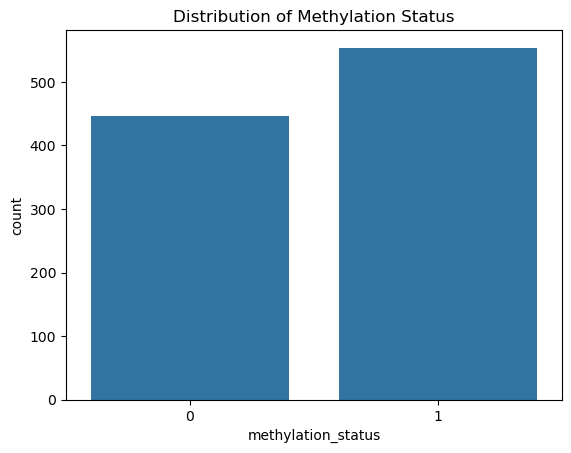

In [7]:
sns.countplot(
    x='methylation_status',
    data=df
)

plt.title("Distribution of Methylation Status")
plt.show()

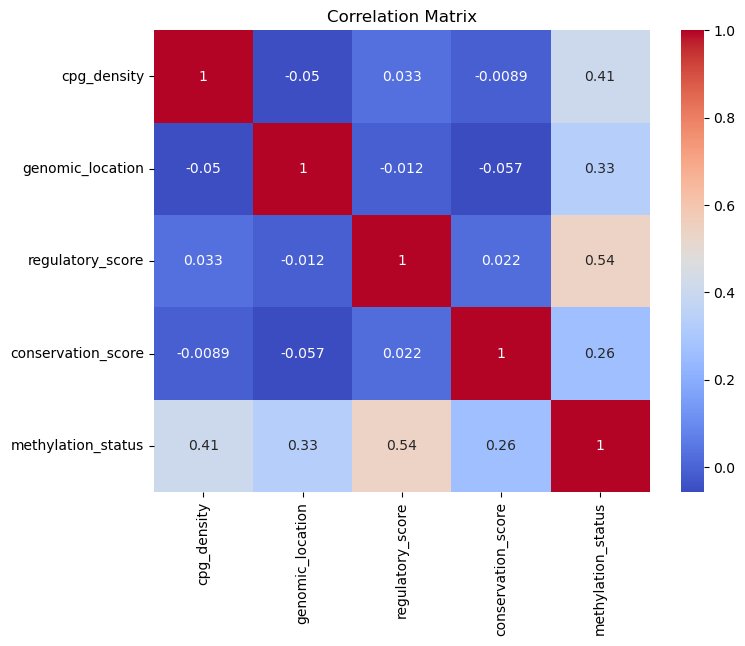

In [8]:
plt.figure(figsize=(8,6))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Matrix")
plt.show()

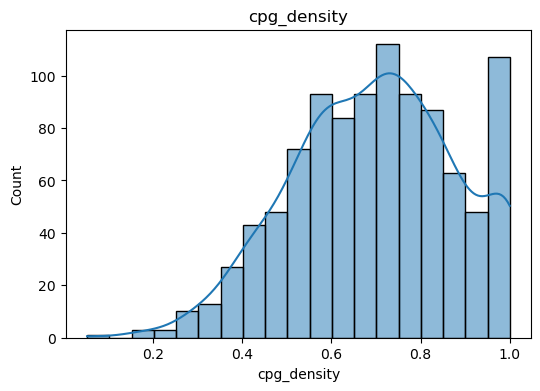

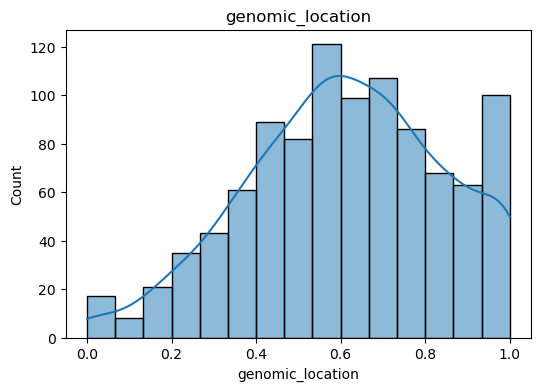

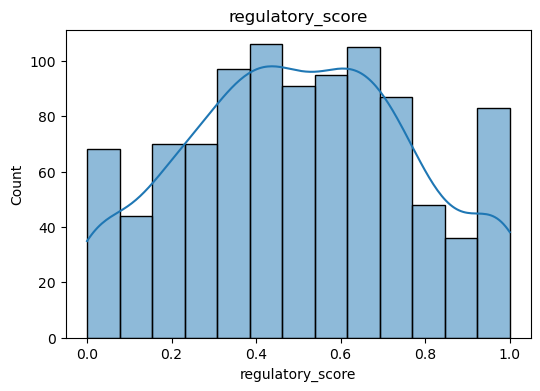

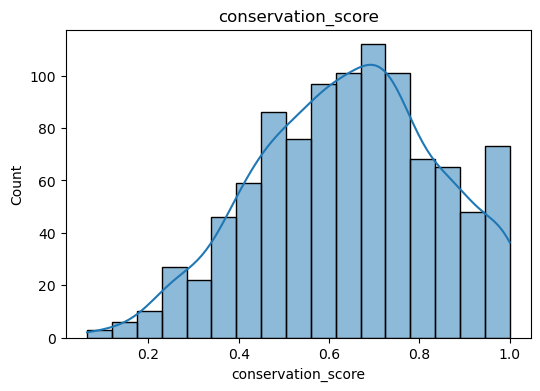

In [9]:
features = [
    'cpg_density',
    'genomic_location',
    'regulatory_score',
    'conservation_score'
]

for col in features:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], kde=True)
    plt.title(col)
    plt.show()

In [11]:
X = df.drop('methylation_status', axis=1)
y = df['methylation_status']

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [15]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [16]:
lr = LogisticRegression()

lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))

Accuracy: 0.985
              precision    recall  f1-score   support

           0       1.00      0.97      0.98        89
           1       0.97      1.00      0.99       111

    accuracy                           0.98       200
   macro avg       0.99      0.98      0.98       200
weighted avg       0.99      0.98      0.98       200



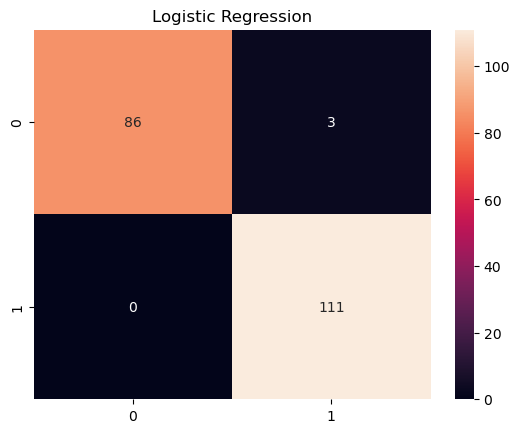

In [17]:
cm = confusion_matrix(y_test, y_pred_lr)

sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

plt.title("Logistic Regression")
plt.show()